## 1. Setup & Imports

# Phage-Host Interaction Dataset for Machine Learning

This notebook demonstrates how to create machine learning datasets from the PBI database for phage-host interaction prediction.

## Contents
1. Setup & Imports
2. Connect to PBI Database
3. Query Phage-Host Pairs
4. Exploratory Data Analysis
5. Feature Engineering
6. Generate Negative Examples
7. Create Balanced Dataset
8. Save Datasets
9. Baseline ML Model
10. Next Steps

In [2]:
# Standard library
import sys
from pathlib import Path

# Add parent directory to path to import pbi
sys.path.insert(0, str(Path.cwd().parent / 'src'))

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# PBI package
from pbi import quick_connect, SequenceRetriever, NegativeExampleGenerator

# Set display options
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')

print("✅ Imports complete")

✅ Imports complete


## 2. Connect to PBI Database

The `quick_connect()` function automatically connects to the default database with all sequence files (phages, proteins, and hosts).

In [3]:
# Connect to database
retriever = quick_connect()


2026-02-18 10:20:06,980 - INFO - 📂 Checking FASTA index files:
2026-02-18 10:20:06,981 - INFO -    Phage index: True (52570.4 KB)
2026-02-18 10:20:06,982 - INFO -    Protein index: True (1432185.2 KB)
2026-02-18 10:20:06,983 - INFO - 📂 Using host mapping file: /data/processed/sequences/host_fasta_mapping.json
2026-02-18 10:20:06,988 - INFO -    Loaded mapping for 5354 hosts
2026-02-18 10:20:06,988 - INFO - 📂 Connecting to database: /data/processed/databases/phage_database_optimized.duckdb
2026-02-18 10:20:07,020 - INFO - 🔄 Starting background FASTA loading...
2026-02-18 10:20:07,021 - INFO - 🔄 [Background] Loading phage FASTA: /data/processed/sequences/all_phages.fasta
2026-02-18 10:20:07,022 - INFO - ✅ Initialization complete (FASTA loading in background)


In [4]:
# Get database statistics
stats = retriever.get_stats()

print("📊 Database Statistics:")
print(f"  Phage Stats: {stats['database']}")
print(f"  Phages in DB: {stats['database']['phages']:,}")
print(f"  Proteins in DB: {stats['database']['proteins']:,}")
print(f"  Hosts in DB: {stats['database']['hosts']:,}")
print(f"  Phage-Host Associations: {stats['database']['phage_host_associations']:,}")
print()
print(f"  Phage sequences: {stats['fasta']['phages']:,}")
print(f"  Protein sequences: {stats['fasta']['proteins']:,}")
print(f"  Host sequences: {stats['fasta']['hosts']:,}")

2026-02-18 10:20:07,032 - INFO - ⏳ Waiting for FASTA loading to complete...
2026-02-18 10:20:23,149 - INFO -    ✅ Phage FASTA loaded in 16.13s (873,717 sequences)
2026-02-18 10:20:23,150 - INFO - 🔄 [Background] Loading protein FASTA: /data/processed/sequences/all_proteins.fasta
2026-02-18 10:25:11,498 - WARNING - ⚠️ Timeout after 300s - FASTA may still be loading
2026-02-18 10:26:51,459 - INFO -    ✅ Protein FASTA loaded in 388.31s (31,050,116 sequences)
2026-02-18 10:26:51,463 - INFO -    ℹ️  Using on-demand loading for 5,354 individual host files
2026-02-18 10:26:51,464 - INFO - 🎉 All FASTA files loaded in 404.44s
2026-02-18 10:26:59,927 - INFO - 🔍 Sample phage keys:
2026-02-18 10:26:59,929 - INFO -    - 'AE002163.1...'
2026-02-18 10:26:59,929 - INFO -    - 'AF009630.1...'
2026-02-18 10:26:59,930 - INFO -    - 'AF011378.1...'
2026-02-18 10:26:59,931 - INFO - 🔍 Sample protein keys:
2026-02-18 10:26:59,932 - INFO -    - 'AE002163.1 AAF39720.1...'
2026-02-18 10:26:59,933 - INFO -    - '

📊 Database Statistics:
  Phage Stats: {'phages': 873718, 'proteins': 43088582, 'hosts': 6029, 'phage_host_associations': 764161}
  Phages in DB: 873,718
  Proteins in DB: 43,088,582
  Hosts in DB: 6,029
  Phage-Host Associations: 764,161

  Phage sequences: 873,717
  Protein sequences: 31,050,116
  Host sequences: 5,354


## 3. Query Phage-Host Pairs

Extract phage-host interaction pairs from the database. These are our positive examples.

In [4]:
# Get all phage-host pairs (limit for testing)
print("📥 Fetching phage-host pairs...")
positive_pairs = retriever.get_phage_host_pairs(limit=1000)

print(f"✅ Retrieved {len(positive_pairs):,} phage-host pairs")
print(f"\nColumns: {list(positive_pairs.columns)}")

# Display sample
positive_pairs.head()

2026-02-03 12:38:27,307 - INFO - 🔍 Querying phage-host pairs...


📥 Fetching phage-host pairs...


2026-02-03 12:38:27,830 - INFO - 📊 Found 1,000 phage-host pairs
2026-02-03 12:38:27,832 - INFO - 📥 Fetching sequences for 1,000 phages and 153 unique hosts
2026-02-03 12:38:46,404 - INFO - ✅ Retrieved 1,000 complete phage-host pairs with sequences


✅ Retrieved 1,000 phage-host pairs

Columns: ['Phage_ID', 'Host_ID', 'Phage_Source', 'Phage_Length', 'Phage_GC', 'Phage_Taxonomy', 'Phage_Completeness', 'Phage_Lifestyle', 'Phage_Cluster', 'Phage_Subcluster', 'Species_Name', 'Host_Assembly_Level', 'Host_Length', 'Host_GC', 'Host_RefSeq_Category', 'Phage_Sequence', 'Host_Sequence']


,Phage_ID,Host_ID,Phage_Source,Phage_Length,Phage_GC,Phage_Taxonomy,Phage_Completeness,Phage_Lifestyle,Phage_Cluster,Phage_Subcluster,Species_Name,Host_Assembly_Level,Host_Length,Host_GC,Host_RefSeq_Category,Phage_Sequence,Host_Sequence
0,Station23_DCM_ALL_assembly_NODE_719_length_207...,GCF_052836085_1,GOV2,20795,51.945179,Caudovirales,None,virulent,cluster_482596,subcluster_580902,Serratia marcescens,Complete Genome,4971147,59.82,na,TGCTTGTCAAGCCCATGACGGTAGGTTCAATACTTCAATTCCTTTG...,GTGTCACTTTCGCTTTGGCAGCAGTGTCTTGCCCGATTGCAGGATG...
1,Station23_DCM_ALL_assembly_NODE_1078_length_16...,GCF_054734815_1,GOV2,16906,41.328522,Caudovirales,None,virulent,cluster_330886,subcluster_399877,Enterobacterales,Complete Genome,5040272,52.14,na,TTCGGGTGGTAGTGCATTGACTGGTAATGACTTATACGTCATTGAA...,CCCTATAATGCGCCACCACTGACACGGAACAACGGCATACAGGCCG...
2,Station23_DCM_ALL_assembly_NODE_1262_length_15...,GCF_054734815_1,GOV2,15610,42.171685,Caudovirales,None,virulent,cluster_467759,subcluster_563157,Enterobacterales,Complete Genome,5040272,52.14,na,TATCTGCGTAGCCTCAAAGACACCGACGGCAAGCTCATGTATCCAG...,CCCTATAATGCGCCACCACTGACACGGAACAACGGCATACAGGCCG...
3,Station23_DCM_ALL_assembly_NODE_1399_length_14...,GCF_047947085_1,GOV2,14728,33.018740,Caudovirales,None,virulent,cluster_339544,subcluster_410188,Prochlorococcus,Complete Genome,1743611,31.12,na,TAGTAGGGTCATTATAACGATTCTTTAACTGTTTAACACATATCTG...,TGCAGTAGATATCGTTGTAAAAGAACAGAATTCATGGATTGCTGGT...
4,Station23_DCM_ALL_assembly_NODE_2593_length_10...,GCF_054734815_1,GOV2,10398,43.796884,Caudovirales,None,virulent,cluster_251983,subcluster_304354,Enterobacterales,Complete Genome,5040272,52.14,na,GAACGATTGGGAATGCAACTGCTGCGAAGCCTTCGACATCGCCACC...,CCCTATAATGCGCCACCACTGACACGGAACAACGGCATACAGGCCG...


In [5]:
# Check for missing values
print("Missing values:")
print(positive_pairs.isnull().sum())

# Data types
print("\nData types:")
print(positive_pairs.dtypes)

Missing values:
Phage_ID                   0
Host_ID                    0
Phage_Source               0
Phage_Length               0
Phage_GC                   0
Phage_Taxonomy            85
Phage_Completeness      1000
Phage_Lifestyle            0
Phage_Cluster              0
Phage_Subcluster           0
Species_Name               0
Host_Assembly_Level        0
Host_Length                0
Host_GC                    0
Host_RefSeq_Category       0
Phage_Sequence             0
Host_Sequence              0
dtype: int64

Data types:
Phage_ID                 object
Host_ID                  object
Phage_Source             object
Phage_Length              int32
Phage_GC                float64
Phage_Taxonomy           object
Phage_Completeness       object
Phage_Lifestyle          object
Phage_Cluster            object
Phage_Subcluster         object
Species_Name             object
Host_Assembly_Level      object
Host_Length               int64
Host_GC                 float64
Host_RefSeq_Categ

## 4. Exploratory Data Analysis

Visualize the distribution of phage and host properties.

In [6]:
# Remove rows with missing sequence data for analysis
df_clean = positive_pairs.dropna(subset=['Phage_GC', 'Host_GC', 'Phage_Length', 'Host_Length'])

print(f"Clean dataset: {len(df_clean):,} pairs (removed {len(positive_pairs) - len(df_clean):,} with missing data)")

Clean dataset: 1,000 pairs (removed 0 with missing data)


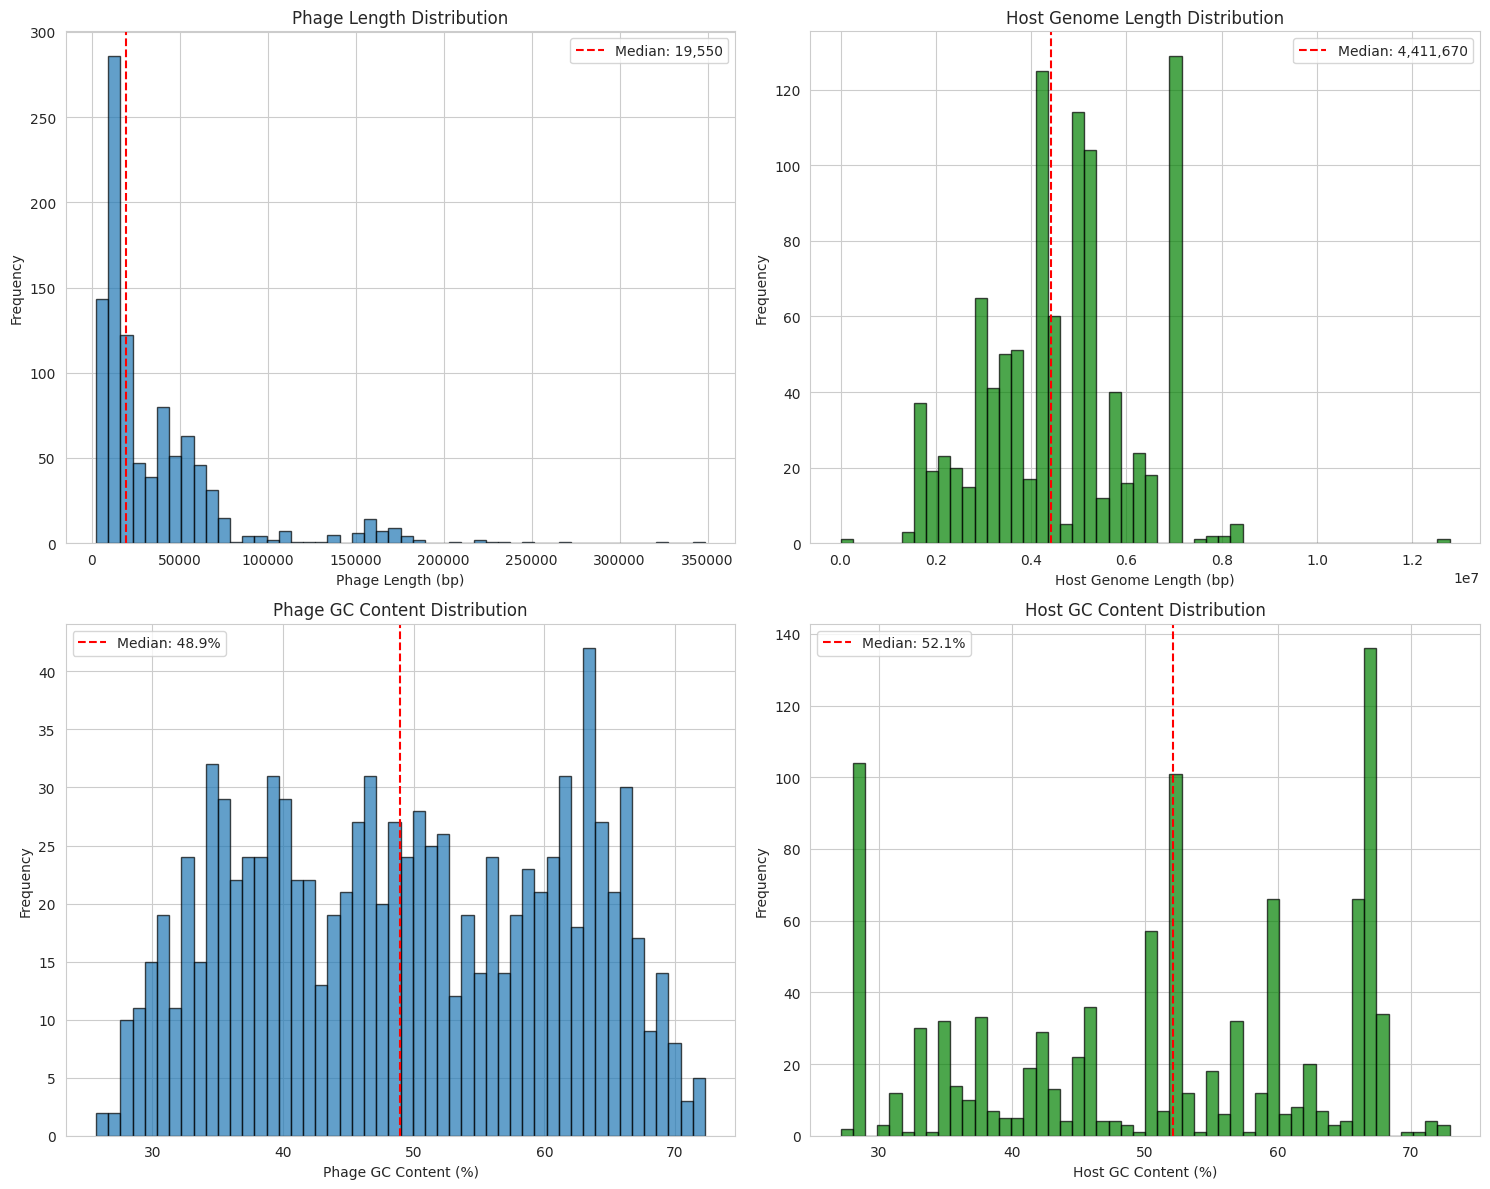

In [7]:
# Plot distributions
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Phage length distribution
axes[0, 0].hist(df_clean['Phage_Length'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Phage Length (bp)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Phage Length Distribution')
axes[0, 0].axvline(df_clean['Phage_Length'].median(), color='red', linestyle='--', label=f'Median: {df_clean["Phage_Length"].median():,.0f}')
axes[0, 0].legend()

# Host genome length distribution
axes[0, 1].hist(df_clean['Host_Length'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[0, 1].set_xlabel('Host Genome Length (bp)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Host Genome Length Distribution')
axes[0, 1].axvline(df_clean['Host_Length'].median(), color='red', linestyle='--', label=f'Median: {df_clean["Host_Length"].median():,.0f}')
axes[0, 1].legend()

# Phage GC content
axes[1, 0].hist(df_clean['Phage_GC'], bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Phage GC Content (%)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Phage GC Content Distribution')
axes[1, 0].axvline(df_clean['Phage_GC'].median(), color='red', linestyle='--', label=f'Median: {df_clean["Phage_GC"].median():.1f}%')
axes[1, 0].legend()

# Host GC content
axes[1, 1].hist(df_clean['Host_GC'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1, 1].set_xlabel('Host GC Content (%)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Host GC Content Distribution')
axes[1, 1].axvline(df_clean['Host_GC'].median(), color='red', linestyle='--', label=f'Median: {df_clean["Host_GC"].median():.1f}%')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

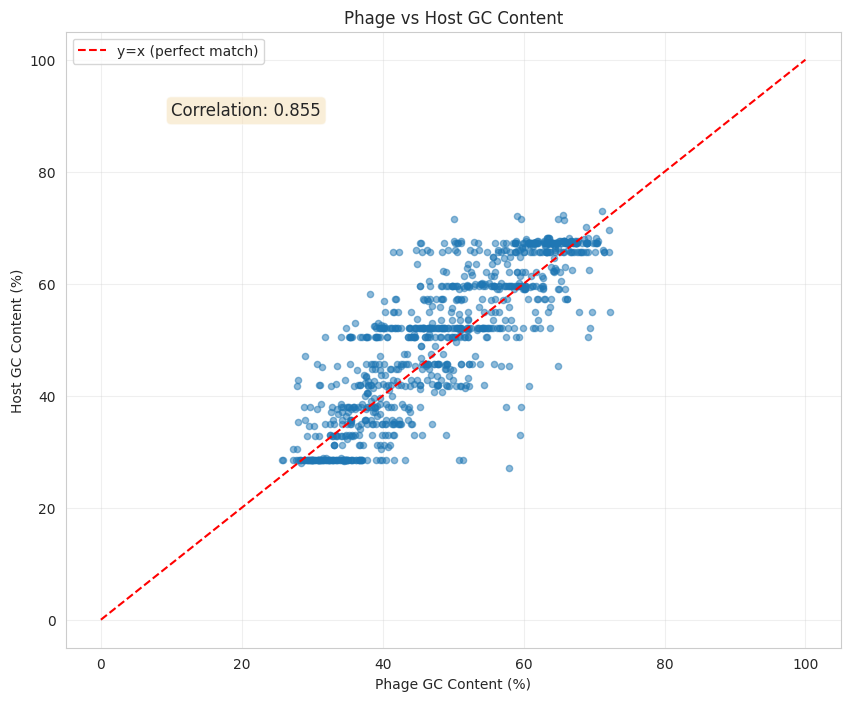

Phage-Host GC Correlation: 0.855


In [8]:
# Phage-Host GC content relationship
plt.figure(figsize=(10, 8))
plt.scatter(df_clean['Phage_GC'], df_clean['Host_GC'], alpha=0.5, s=20)
plt.xlabel('Phage GC Content (%)')
plt.ylabel('Host GC Content (%)')
plt.title('Phage vs Host GC Content')
plt.plot([0, 100], [0, 100], 'r--', label='y=x (perfect match)')
plt.legend()
plt.grid(True, alpha=0.3)

# Calculate correlation
correlation = df_clean['Phage_GC'].corr(df_clean['Host_GC'])
plt.text(10, 90, f'Correlation: {correlation:.3f}', fontsize=12, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.show()

print(f"Phage-Host GC Correlation: {correlation:.3f}")

Top 10 Host Species:
Species_Name
Mycobacterium smegmatis        66
Mycolicibacterium smegmatis    48
Enterobacterales               26
Peptostreptococcaceae          25
Clostridioides difficile       25
Salmonella                     25
Enterobacteriaceae             25
Escherichia coli               24
Bacillus cereus                22
Clostridioides                 19
Name: count, dtype: int64


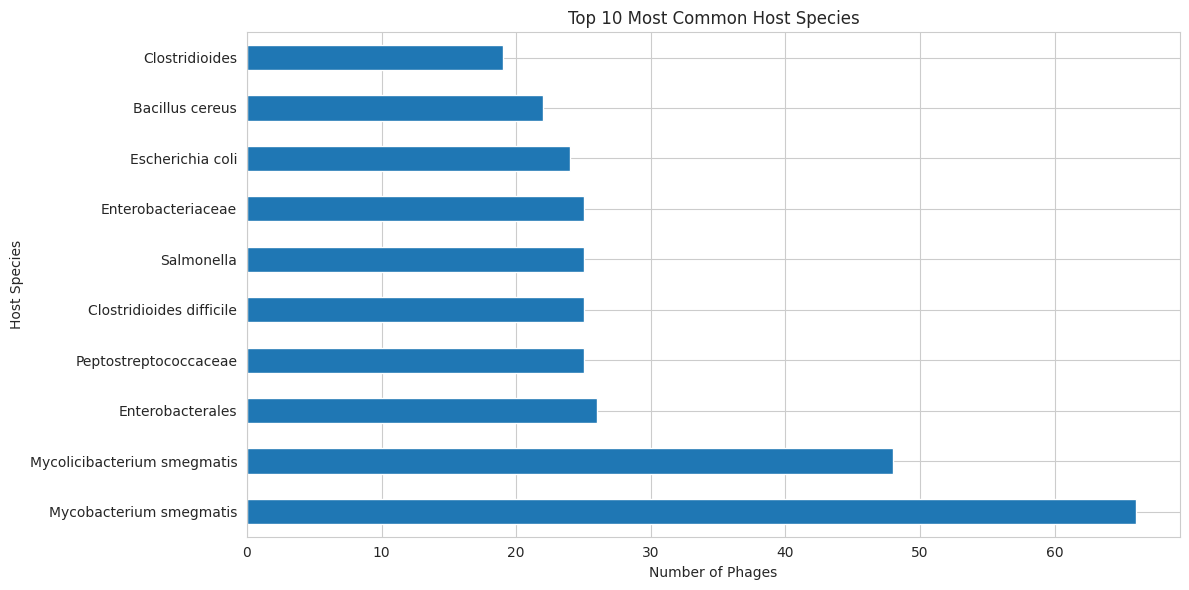

In [9]:
# Host species distribution
print("Top 10 Host Species:")
host_counts = df_clean['Species_Name'].value_counts().head(10)
print(host_counts)

# Plot
plt.figure(figsize=(12, 6))
host_counts.plot(kind='barh')
plt.xlabel('Number of Phages')
plt.ylabel('Host Species')
plt.title('Top 10 Most Common Host Species')
plt.tight_layout()
plt.show()

## 5. Feature Engineering

Create features for machine learning from sequence properties.

In [10]:
def engineer_features(df):
    """Create features from phage-host pairs"""
    features = df.copy()
    
    # GC content features
    features['GC_Difference'] = abs(features['Phage_GC'] - features['Host_GC'])
    features['GC_Ratio'] = features['Phage_GC'] / (features['Host_GC'] + 1e-6)
    features['GC_Sum'] = features['Phage_GC'] + features['Host_GC']
    
    # Length features
    features['Length_Ratio'] = features['Phage_Length'] / (features['Host_Length'] + 1)
    features['Log_Phage_Length'] = np.log10(features['Phage_Length'] + 1)
    features['Log_Host_Length'] = np.log10(features['Host_Length'] + 1)
    
    # Interaction features
    features['GC_x_Length_Ratio'] = features['GC_Ratio'] * features['Length_Ratio']
    
    return features

# Apply feature engineering
df_features = engineer_features(df_clean)

print("Engineered features:")
print(df_features[['GC_Difference', 'GC_Ratio', 'Length_Ratio', 'GC_x_Length_Ratio']].describe())

Engineered features:
       GC_Difference     GC_Ratio  Length_Ratio  GC_x_Length_Ratio
count    1000.000000  1000.000000   1000.000000        1000.000000
mean        5.416093     0.986769      0.009653           0.009307
std         4.591610     0.153850      0.033453           0.033336
min         0.003747     0.615598      0.000455           0.000396
25%         1.955696     0.898381      0.002653           0.002675
50%         4.193610     0.972921      0.005345           0.005500
75%         7.392915     1.056103      0.009884           0.009744
max        30.835545     2.136166      0.999758           0.999853


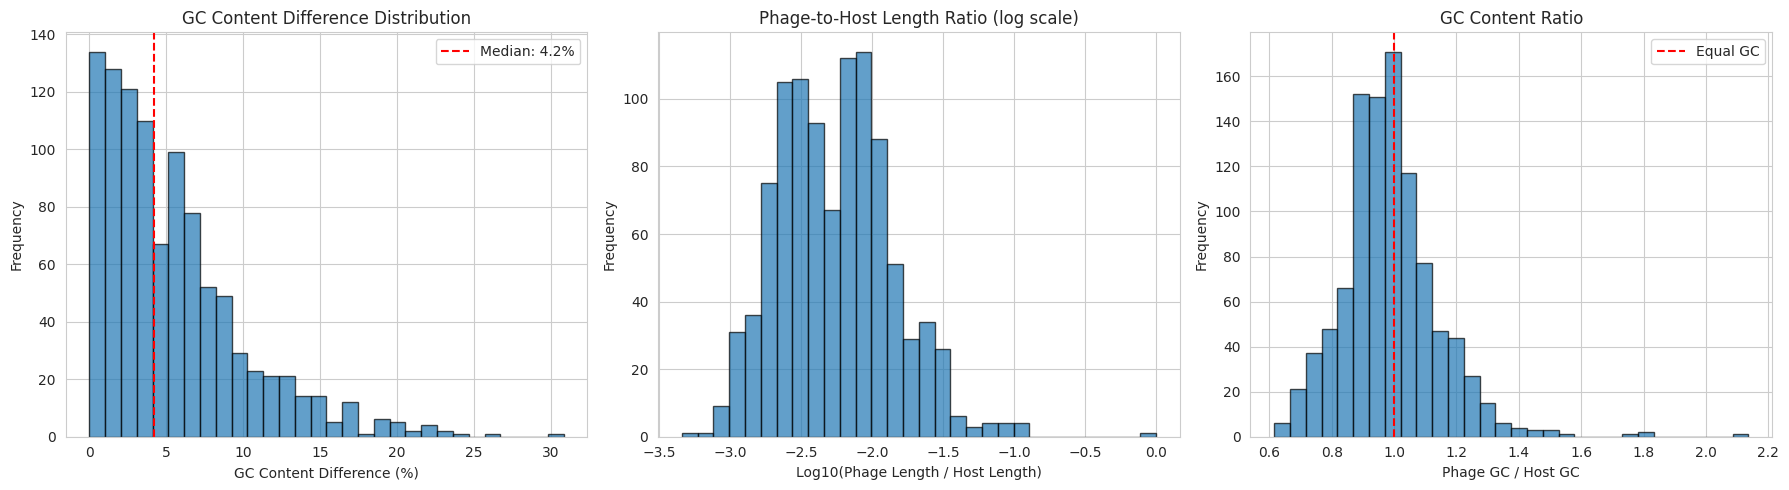

In [11]:
# Visualize key features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# GC Difference
axes[0].hist(df_features['GC_Difference'], bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('GC Content Difference (%)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('GC Content Difference Distribution')
axes[0].axvline(df_features['GC_Difference'].median(), color='red', linestyle='--', 
                label=f'Median: {df_features["GC_Difference"].median():.1f}%')
axes[0].legend()

# Length Ratio (log scale)
axes[1].hist(np.log10(df_features['Length_Ratio']), bins=30, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Log10(Phage Length / Host Length)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Phage-to-Host Length Ratio (log scale)')

# GC Ratio
axes[2].hist(df_features['GC_Ratio'], bins=30, edgecolor='black', alpha=0.7)
axes[2].set_xlabel('Phage GC / Host GC')
axes[2].set_ylabel('Frequency')
axes[2].set_title('GC Content Ratio')
axes[2].axvline(1.0, color='red', linestyle='--', label='Equal GC')
axes[2].legend()

plt.tight_layout()
plt.show()

## 6. Generate Negative Examples

Create non-interacting phage-host pairs for training a binary classifier.

In [12]:
# Initialize negative example generator
neg_gen = NegativeExampleGenerator(retriever)

print("✅ NegativeExampleGenerator initialized")

2026-02-03 12:40:39,476 - INFO - 📊 Cached 873,718 phages and 0 hosts
2026-02-03 12:40:39,478 - INFO - ✅ NegativeExampleGenerator initialized
2026-02-03 12:40:39,479 - INFO -    Available phages: 873,718
2026-02-03 12:40:39,480 - INFO -    Available hosts: 0


✅ NegativeExampleGenerator initialized


In [13]:
# Generate random negatives (1:1 ratio)
print("🎲 Generating random negative examples...")
negatives_random = neg_gen.generate_random_negatives(positive_pairs, ratio=1.0)

print(f"✅ Generated {len(negatives_random):,} random negatives")
negatives_random.head()

2026-02-03 12:40:40,772 - INFO - 🎲 Generating random negative examples...
2026-02-03 12:40:40,775 - INFO -    Target: 1,000 negatives from 1,000 positives
2026-02-03 12:40:40,777 - INFO -    Positive set size: 995


🎲 Generating random negative examples...


ValueError: a must be greater than 0 unless no samples are taken

✅ Generated 1,000 random negatives


,Phage_ID,Host_ID,Phage_GC,Phage_Length,Host_GC,Host_Length,Label
0,Station138_DCM_ALL_assembly_NODE_37_length_542...,GCF_048688125_1,40.220279,54204,32.71,2748751,0
1,Station125_SUR_ALL_assembly_NODE_1211_length_1...,GCF_004295585_1,35.414391,16482,44.83,7059027,0
2,SAMEA1906574_a1_ct43393_vs1,GCF_053604725_1,38.944738,17607,69.48,8859018,0
3,Han_2018_ERR1398214_NODE_2026_length_11607_cov...,GCF_000969705_1,52.968037,11607,72.05,5558097,0
4,SAMN10290194_a1_ct878,GCF_000264315_1,37.094281,6470,65.59,3879600,0


In [14]:
# Generate GC-based negatives
print("🧬 Generating GC-based negative examples...")
negatives_gc = neg_gen.generate_gc_based_negatives(
    positive_pairs, 
    ratio=0.5,
    min_gc_difference=20.0
)

print(f"✅ Generated {len(negatives_gc):,} GC-based negatives")
print(f"Mean GC difference: {negatives_gc['GC_Difference'].mean():.1f}%")

2026-02-16 13:11:27,944 - INFO - 🧬 Generating GC-based negative examples (min diff: 20.0%)...


🧬 Generating GC-based negative examples...


2026-02-16 13:11:36,357 - INFO -    Generated 100/500 negatives...
2026-02-16 13:11:36,379 - INFO -    Generated 100/500 negatives...
2026-02-16 13:11:36,400 - INFO -    Generated 100/500 negatives...
2026-02-16 13:11:36,422 - INFO -    Generated 100/500 negatives...
2026-02-16 13:11:43,409 - INFO -    Generated 200/500 negatives...
2026-02-16 13:11:43,431 - INFO -    Generated 200/500 negatives...
2026-02-16 13:11:43,452 - INFO -    Generated 200/500 negatives...
2026-02-16 13:11:43,473 - INFO -    Generated 200/500 negatives...
2026-02-16 13:11:43,493 - INFO -    Generated 200/500 negatives...
2026-02-16 13:11:43,514 - INFO -    Generated 200/500 negatives...
2026-02-16 13:11:43,534 - INFO -    Generated 200/500 negatives...
2026-02-16 13:11:43,555 - INFO -    Generated 200/500 negatives...
2026-02-16 13:11:50,740 - INFO -    Generated 300/500 negatives...
2026-02-16 13:11:50,762 - INFO -    Generated 300/500 negatives...
2026-02-16 13:11:50,782 - INFO -    Generated 300/500 negative

✅ Generated 500 GC-based negatives
Mean GC difference: 27.5%


## 7. Create Balanced Dataset

Combine positive and negative examples into a balanced training dataset.

In [15]:
# Generate balanced dataset with mixed strategy
print("🔨 Creating balanced dataset...")
dataset = neg_gen.generate_balanced_dataset(
    positive_pairs=positive_pairs,
    strategy='mixed',
    positive_ratio=0.5
)

print(f"\n✅ Dataset created:")
print(f"   Total samples: {len(dataset):,}")
print(f"   Positives: {(dataset['Label'] == 1).sum():,}")
print(f"   Negatives: {(dataset['Label'] == 0).sum():,}")

dataset.head()

2026-02-16 13:12:05,192 - INFO - 🔨 Generating balanced dataset (strategy: mixed, ratio: 0.5)...
2026-02-16 13:12:05,194 - INFO -    Target: 1,000 positives, 1,000 negatives
2026-02-16 13:12:05,195 - INFO - 🎲 Generating random negative examples...
2026-02-16 13:12:05,196 - INFO -    Target: 333 negatives from 1,000 positives
2026-02-16 13:12:05,197 - INFO -    Positive set size: 984


🔨 Creating balanced dataset...


2026-02-16 13:12:07,182 - INFO -    Generated 100/333 negatives...
2026-02-16 13:12:09,166 - INFO -    Generated 200/333 negatives...
2026-02-16 13:12:11,147 - INFO -    Generated 300/333 negatives...
2026-02-16 13:12:11,804 - INFO - ✅ Generated 333 random negative pairs
2026-02-16 13:12:11,805 - INFO - 🧬 Generating GC-based negative examples (min diff: 20.0%)...
2026-02-16 13:12:18,749 - INFO -    Generated 100/333 negatives...
2026-02-16 13:12:18,770 - INFO -    Generated 100/333 negatives...
2026-02-16 13:12:18,791 - INFO -    Generated 100/333 negatives...
2026-02-16 13:12:18,811 - INFO -    Generated 100/333 negatives...
2026-02-16 13:12:18,832 - INFO -    Generated 100/333 negatives...
2026-02-16 13:12:18,852 - INFO -    Generated 100/333 negatives...
2026-02-16 13:12:18,873 - INFO -    Generated 100/333 negatives...
2026-02-16 13:12:26,292 - INFO -    Generated 200/333 negatives...
2026-02-16 13:12:26,314 - INFO -    Generated 200/333 negatives...
2026-02-16 13:12:26,335 - INFO 


✅ Dataset created:
   Total samples: 1,999
   Positives: 1,000
   Negatives: 999


,Phage_ID,Host_ID,Phage_Source,Phage_Length,Phage_GC,Phage_Taxonomy,Phage_Completeness,Phage_Lifestyle,Phage_Cluster,Phage_Subcluster,Species_Name,Host_Assembly_Level,Host_Length,Host_GC,Host_RefSeq_Category,Phage_Sequence,Host_Sequence,Label,GC_Difference,Host_Species
0,Station70_SUR_ALL_assembly_NODE_1809_length_14...,GCF_054790975_1,GOV2,14906,34.804777,Caudovirales,None,virulent,cluster_388785,subcluster_469521,Clostridium difficile,Complete Genome,4168273,28.51,na,ATTAATTTACTCCTATATGCTTAATTATATCAAAATCTCGAGGTCA...,ATGGATATAGTTTCTTTATGGGACAAAACCCTACAATTAATAAAAG...,1,NaN,NaN
1,biochar_1892,GCF_054693465_1,STV,22961,62.109664,Caudoviricetes,None,temperate,cluster_509905,subcluster_614167,Klebsiella pneumoniae,Complete Genome,5791791,57.21,na,AGAAGCCGCGCGACCGCTGGAACAACTCGGACGACGACGAGCCTAG...,CATTATTGGCGCGTGGTTCCTGCTGCAAACCCACTGGGGCGCCCGC...,1,NaN,NaN
2,biochar_677,GCF_054693465_1,STV,42877,60.673555,Caudoviricetes,None,temperate,cluster_243296,subcluster_294235,Klebsiella pneumoniae,Complete Genome,5791791,57.21,na,AAACGCTGCGCCAGTAATTTCCGAAATAGCGCGACCCATGCTCGAC...,CATTATTGGCGCGTGGTTCCTGCTGCAAACCCACTGGGGCGCCCGC...,1,NaN,NaN
3,DQ079899.1,GCF_054696555_1,Genbank,5577,45.956607,Microviridae,None,virulent,cluster_177517,subcluster_224073,Escherichia coli,Complete Genome,5116364,50.49,na,TGCTTGACTAATACTCAATCACCACTCTAATATGCCTCCCATCAAA...,GGATTCTTTACAAATAACTCACAAGTTAACTCTAGAACGGAATGTC...,1,NaN,NaN
4,uvig_158120,GCF_044793645_1,NaN,13267,46.272707,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5411308,41.64,NaN,NaN,NaN,0,NaN,NaN


In [16]:
# Apply feature engineering to full dataset
dataset_clean = dataset.dropna(subset=['Phage_GC', 'Host_GC', 'Phage_Length', 'Host_Length'])
dataset_features = engineer_features(dataset_clean)

print(f"Dataset with features: {len(dataset_features):,} samples")
print(f"Feature columns: {[col for col in dataset_features.columns if col not in positive_pairs.columns]}")

Dataset with features: 1,999 samples
Feature columns: ['GC_Difference', 'Host_Species', 'GC_Ratio', 'GC_Sum', 'Length_Ratio', 'Log_Phage_Length', 'Log_Host_Length', 'GC_x_Length_Ratio']


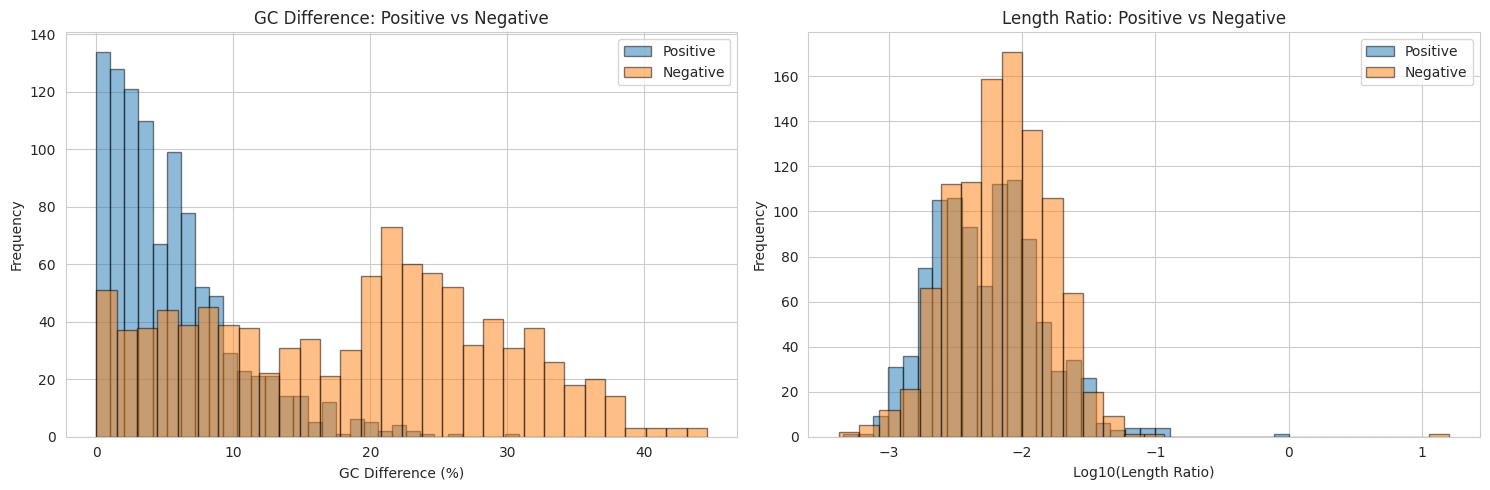

In [17]:
# Compare positive and negative distributions
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# GC Difference comparison
positive_data = dataset_features[dataset_features['Label'] == 1]['GC_Difference']
negative_data = dataset_features[dataset_features['Label'] == 0]['GC_Difference']

axes[0].hist(positive_data, bins=30, alpha=0.5, label='Positive', edgecolor='black')
axes[0].hist(negative_data, bins=30, alpha=0.5, label='Negative', edgecolor='black')
axes[0].set_xlabel('GC Difference (%)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('GC Difference: Positive vs Negative')
axes[0].legend()

# Length Ratio comparison (log scale)
positive_ratio = dataset_features[dataset_features['Label'] == 1]['Length_Ratio']
negative_ratio = dataset_features[dataset_features['Label'] == 0]['Length_Ratio']

axes[1].hist(np.log10(positive_ratio), bins=30, alpha=0.5, label='Positive', edgecolor='black')
axes[1].hist(np.log10(negative_ratio), bins=30, alpha=0.5, label='Negative', edgecolor='black')
axes[1].set_xlabel('Log10(Length Ratio)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Length Ratio: Positive vs Negative')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Save Datasets

Export datasets for use in ML training.

**Note:** Datasets are saved to `/workspace/ml_datasets/` which is local to the analysis container.

**To access exported files:**
- **Inside the container:** Files are available at `/workspace/ml_datasets/`
- **From your host machine:** 
  - Use `docker cp` to copy files from the container to your host:
    ```bash
    docker cp pbi-analysis:/workspace/ml_datasets/phage_host_features.csv ./
    ```
  - Or mount `/workspace` as a volume when starting the container (see docker-compose.yml)


In [18]:
# Define feature columns for ML
feature_cols = [
    'Phage_Length', 'Phage_GC',
    'Host_Length', 'Host_GC',
    'GC_Difference', 'GC_Ratio', 'GC_Sum',
    'Length_Ratio', 'Log_Phage_Length', 'Log_Host_Length',
    'GC_x_Length_Ratio'
]

# Create features-only dataset
ml_dataset = dataset_features[feature_cols + ['Label']].copy()

print(f"ML Dataset: {len(ml_dataset):,} samples x {len(feature_cols)} features")
print(f"\nFeature columns:")
for col in feature_cols:
    print(f"  - {col}")

ML Dataset: 1,999 samples x 11 features

Feature columns:
  - Phage_Length
  - Phage_GC
  - Host_Length
  - Host_GC
  - GC_Difference
  - GC_Ratio
  - GC_Sum
  - Length_Ratio
  - Log_Phage_Length
  - Log_Host_Length
  - GC_x_Length_Ratio


In [19]:
# Save datasets
# Use /workspace for writable storage in the analysis container
output_dir = Path('/workspace/ml_datasets')
output_dir.mkdir(parents=True, exist_ok=True)

# Save full dataset with sequences (parquet for efficiency)
dataset_features.to_parquet(output_dir / 'phage_host_dataset_full.parquet', index=False)
print(f"✅ Saved: {output_dir / 'phage_host_dataset_full.parquet'}")

# Save features-only dataset (CSV for compatibility)
ml_dataset.to_csv(output_dir / 'phage_host_features.csv', index=False)
print(f"✅ Saved: {output_dir / 'phage_host_features.csv'}")

# Save positive pairs only
positive_pairs.to_csv(output_dir / 'positive_pairs.csv', index=False)
print(f"✅ Saved: {output_dir / 'positive_pairs.csv'}")

OSError: [Errno 30] Read-only file system: '../data/ml_datasets'

## 9. Baseline ML Model

Train a simple Random Forest classifier as a baseline.

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

print("✅ ML libraries imported")

ModuleNotFoundError: No module named 'sklearn'

In [21]:
# Prepare data
X = ml_dataset[feature_cols]
y = ml_dataset['Label']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {len(X_train):,} samples")
print(f"Test set: {len(X_test):,} samples")
print(f"\nClass balance (train):")
print(y_train.value_counts())

NameError: name 'train_test_split' is not defined

In [ ]:
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Features standardized")

In [ ]:
# Train Random Forest
print("🌲 Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)
print("✅ Model trained")

In [ ]:
# Evaluate on test set
y_pred = rf_model.predict(X_test_scaled)
y_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

print("📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

# ROC-AUC
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"\nROC-AUC Score: {auc_score:.3f}")

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 5 Most Important Features:")
print(feature_importance.head())

## 10. Next Steps

### Advanced ML Approaches

1. **Sequence-based Features**
   - K-mer frequencies (DNA/protein)
   - Codon usage patterns
   - Protein domain annotations
   - CRISPR spacer matches

2. **Deep Learning**
   - CNN/LSTM for sequence modeling
   - Transformer models (DNA-BERT, etc.)
   - Graph neural networks (phage-host networks)

3. **Advanced Models**
   - Gradient Boosting (XGBoost, LightGBM)
   - Ensemble methods
   - Neural networks

4. **Feature Engineering**
   - Taxonomic embeddings
   - Host receptor proteins
   - Phage structural proteins
   - Lifestyle-specific features

### Use Cases

- **Host Range Prediction**: Predict which hosts a phage can infect
- **Therapeutic Candidate Selection**: Identify phages for specific bacterial infections
- **Lifestyle Classification**: Predict lytic vs lysogenic based on sequences
- **Protein Function Prediction**: Classify protein functions

### Resources

- [PBI Documentation](https://thibaultschowing.github.io/PBI/)
- [Machine Learning Guide](https://thibaultschowing.github.io/PBI/guides/machine-learning/)
- [Database Schema](https://thibaultschowing.github.io/PBI/database/schema/)

In [ ]:
# Cleanup
retriever.close()
print("✅ Database connection closed")